# GLMsingle: Single-trial beta estimation (pseudo-run approach)

This notebook runs **GLMsingle** treating each **block** in the events file as a separate pseudo-run.

### Why pseudo-runs?
GLMsingle's most powerful models (`typec`, `typed`) require multiple runs for cross-validation and ridge regression. If your data was acquired as one long run but contains distinct blocks, you can split by block to unlock these models.

### What does this notebook do?
1. Loads your fMRI data and events file
2. Splits events by `block` column → one design matrix + one BOLD segment per block
3. Runs GLMsingle with the per-block lists (enabling `typec`/`typed` if ≥2 blocks)
4. Averages betas by condition and visualizes the results
5. Saves everything to disk

## 1. Imports

In [1]:
# If any imports fail: pip install <name>
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from nilearn import plotting, image
from glmsingle.glmsingle import GLM_single

%matplotlib inline
print('All imports OK')

All imports OK


## 2. File paths
Set your file paths here. This is the only section you need to edit when running on new data.

In [2]:
# --- EDIT THESE ---

#mask_path = '/jukebox/PNI-classes/students/NEU502/2026-NEU502B/binary_shaef.nii'

## sub 008
# bold_path   = '/jukebox/PNI-classes/students/NEU502/2026-NEU502B/binding_group/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-008/ses-01/func/sub-008_ses-01_task-perceptXbind_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz'
# mask_path = '/jukebox/PNI-classes/students/NEU502/2026-NEU502B/binding_group/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-008/ses-01/anat/sub-008_ses-01_space-MNI152NLin2009cAsym_res-2_label-GM_probseg.nii.gz'
#events_path = 'e3f4c2c2-e078-42a1-970c-cc7833d2a7b2_shape_onsets.tsv'

## sub 002
# bold_path   = '/jukebox/graziano/kirsten/502b_percept_new/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-002/ses-01/func/sub-002_ses-01_task-perceptXbind_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz'
# mask_path = '/jukebox/graziano/kirsten/502b_percept_new/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-002/ses-01/anat/sub-002_ses-01_space-MNI152NLin2009cAsym_label-GM_probseg.nii.gz'
# events_path = '/usr/people/gw0402/NEU502B/brain-binding/data/2026-03-02_16-25-49/7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99_shape_onsets.tsv'

## sub 001
bold_path   = '/jukebox/graziano/kirsten/502b_percept_new/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-001/ses-01/func/sub-001_combined_files/sub-001_MNI_combo.nii.gz'
mask_path = '/jukebox/graziano/kirsten/502b_percept_new/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-001/ses-01/anat/sub-001_ses-01_space-MNI152NLin2009cAsym_label-GM_probseg.nii.gz'
events_path = 'sub-001_combined_times_shape_onsets.tsv'

output_dir  = '/usr/people/ao8210/neu502b/results/pseudoruns'
os.makedirs(output_dir, exist_ok=True)
print('Output dir:', output_dir)
print('Mask path: ', mask_path if mask_path else '(auto-generated from mean BOLD)')

Output dir: /usr/people/ao8210/neu502b/results/pseudoruns
Mask path:  /jukebox/graziano/kirsten/502b_percept_new/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-001/ses-01/anat/sub-001_ses-01_space-MNI152NLin2009cAsym_label-GM_probseg.nii.gz


## 3. Load data

In [5]:
bold_img  = nib.load(bold_path)
bold_data = bold_img.get_fdata().astype(np.float32)  # shape: (X, Y, Z, T)

TR    = float(bold_img.header.get_zooms()[3])  # repetition time in seconds
n_trs = bold_data.shape[3]

print(f'BOLD shape : {bold_data.shape}')
print(f'TR         : {TR} s')
print(f'Total time : {n_trs * TR:.1f} s ({n_trs} TRs)')

BOLD shape : (78, 93, 78, 769)
TR         : 1.0 s
Total time : 769.0 s (769 TRs)


In [3]:
events = pd.read_table(events_path)
print(f'N trials    : {len(events)}')
print(f'Blocks      : {events["block"].unique()}')
print(f'Trial types : {events["trial_type"].unique()}')
events.head()

N trials    : 600
Blocks      : ['main_run1' 'main_run2' 'main_run3' 'main_run4']
Trial types : ['circle' 'triangle' 'rectangle' 'star']


,onset,duration,trial_type,run,block,trial,phase,position,rule_type
0,145.109745,0.541940,circle,1,main_run1,0,rule,1,ABA
1,146.442993,0.535193,triangle,1,main_run1,0,rule,2,ABA
2,148.159214,0.535679,circle,1,main_run1,0,rule,3,ABA
3,149.342894,0.542016,triangle,1,main_run1,0,test,1,ABA
4,150.842921,0.551065,circle,1,main_run1,0,test,2,ABA


## 4. Build per-block design matrices

Each unique value in the `block` column becomes a **pseudo-run**. For each block we:
- Find the TR range it spans in the full time series
- Build a design matrix with **block-relative** TR indices (rows = TRs within the block, cols = trials in the block)
- Record which BOLD TRs to slice out

We also track `trial_order` — the original `events` row indices in the order GLMsingle will return betas — so we can map betas back to the original events table later.

Blocks found (4 total): ['main_run1', 'main_run2', 'main_run3', 'main_run4']

72
253
  main_run1: TRs 72–253 (181 TRs, 150 trials, 41 estimable)  design shape: (181, 150)
256
430
  main_run2: TRs 256–430 (174 TRs, 150 trials, 40 estimable)  design shape: (174, 150)
484
659
  main_run3: TRs 484–659 (175 TRs, 150 trials, 44 estimable)  design shape: (175, 150)
663
769
  main_run4: TRs 663–769 (106 TRs, 150 trials, 22 estimable)  design shape: (106, 150)

Total estimable trials: 147 / 600


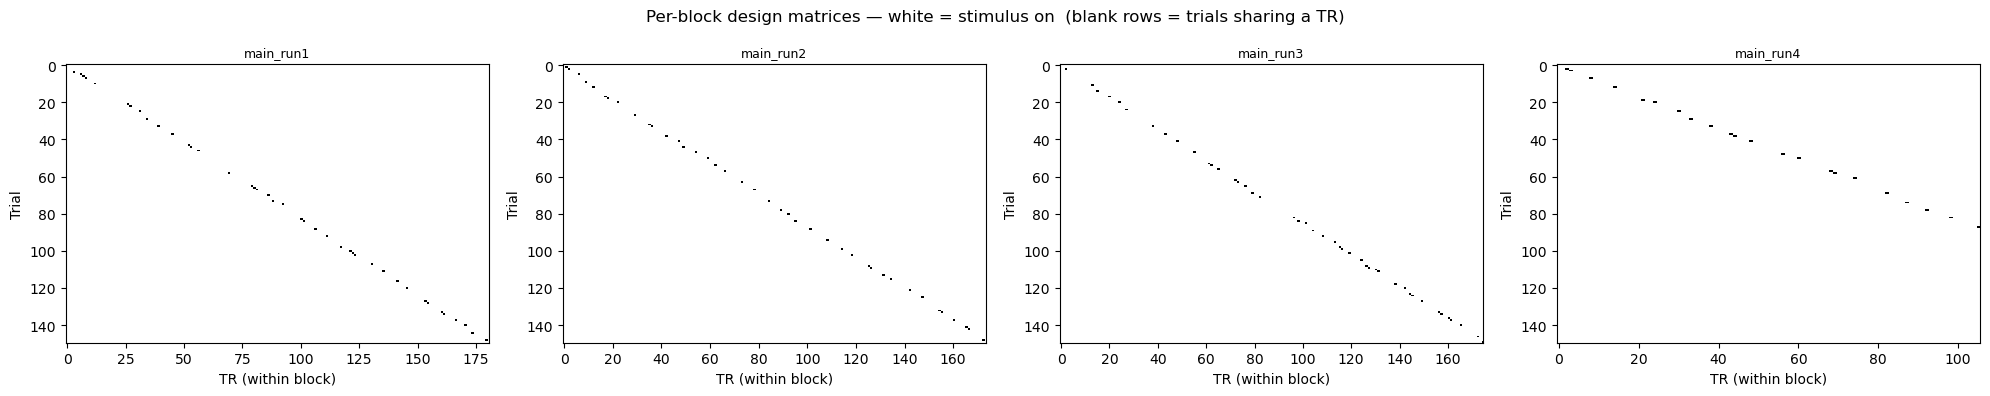

In [9]:
TR = 2.0
# Sort blocks chronologically by the first onset in each block
block_order = events.groupby('block')['onset'].min().sort_values().index.tolist()
print(f'Blocks found ({len(block_order)} total): {block_order}\n')

designs         = []  # per-block design matrices
block_tr_ranges = []  # (start_tr, end_tr) for slicing BOLD
trial_order     = []  # original events row indices for trials that GLMsingle will return betas for
                      # (trials whose onset+duration round to the same TR are skipped — GLMsingle
                      #  cannot separate two conditions that share an onset TR)

for block in block_order:
    block_mask   = events['block'] == block
    block_events = events[block_mask]
    onsets_s     = block_events['onset'].values
    #response_s  = block_events['t_response'].values
    durations_s = block_events['duration'].values

    block_start_tr = int(np.floor(onsets_s.min() / TR))
    block_end_tr   = min(int(np.ceil((onsets_s + durations_s).max() / TR)), n_trs)
    block_n_trs    = block_end_tr - block_start_tr
    print(block_start_tr)
    print(block_end_tr)

    block_design = np.zeros((block_n_trs, len(block_events)), dtype=np.float32)
    for j, (_, row) in enumerate(block_events.iterrows()):
        local_on  = max(0, int(np.round(row['onset'] / TR)) - block_start_tr)
        local_off = min(block_n_trs,
                        int(np.round((row['onset'] + row['duration']) / TR)) - block_start_tr)
        block_design[local_on:local_off, j] = 1

    designs.append(block_design)
    block_tr_ranges.append((block_start_tr, block_end_tr))

    # Only track trials whose design column is non-zero; GLMsingle returns betas only
    # for those.  Trials shorter than one TR often round to zero duration and stay
    # all-zero — they share a TR onset with an adjacent trial and cannot be separated.
    valid_cols = [j for j in range(len(block_events)) if block_design[:, j].sum() > 0]
    trial_order.extend(block_events.index[valid_cols].tolist())

    n_valid = len(valid_cols)
    print(f'  {block}: TRs {block_start_tr}–{block_end_tr} '
          f'({block_n_trs} TRs, {len(block_events)} trials, {n_valid} estimable)  '
          f'design shape: {block_design.shape}')

print(f'\nTotal estimable trials: {len(trial_order)} / {len(events)}')

# Visualise all design matrices
fig, axes = plt.subplots(1, len(designs), figsize=(5 * len(designs), 4))
if len(designs) == 1:
    axes = [axes]
for ax, d, block in zip(axes, designs, block_order):
    ax.imshow(d.T, aspect='auto', cmap='gray_r', interpolation='nearest')
    ax.set_title(block, fontsize=9)
    ax.set_xlabel('TR (within block)')
    ax.set_ylabel('Trial')
plt.suptitle('Per-block design matrices — white = stimulus on  (blank rows = trials sharing a TR)')
plt.tight_layout()
plt.show()


## 5. Stimulus duration (`stimdur`)

`stimdur` tells GLMsingle how long each stimulus lasts, used to construct the expected BOLD response. Because we already encoded each trial's actual duration directly in the design matrix (as a run of 1s), we set `stimdur = TR` to avoid double-counting.

In [10]:
stimdur = TR
print(f'stimdur = {stimdur} s (= TR)')
print(f'Trial durations: {events["duration"].min():.2f} – {events["duration"].max():.2f} s')

stimdur = 2.0 s (= TR)
Trial durations: 0.52 – 0.56 s


## 6. Mask the data and run GLMsingle

We first build a brain mask (to skip non-brain voxels), then flatten the 4D BOLD to 2D (voxels × TRs), then **slice out one BOLD segment per block** matching each design matrix.

GLMsingle receives two parallel lists — `designs` and `bold_segments` — one entry per pseudo-run (block). With multiple pseudo-runs it can run **GLMdenoise** and **ridge regression** (`typec`, `typed`), giving better beta estimates than a single-run analysis.

In [11]:
import shutil

mean_bold_img  = image.mean_img(bold_img)
mean_bold_data = mean_bold_img.get_fdata()

if mask_path is not None:
    mask_img  = nib.load(mask_path)
    mask_img  = image.resample_to_img(mask_img, bold_img, interpolation='nearest')
    mask_data = mask_img.get_fdata()
    if mask_data.max() <= 1.0 and mask_data.dtype != np.uint8:
        gm_threshold  = 0.4
        brain_mask_3d = mask_data > gm_threshold
        print(f'Loaded probability mask, thresholded at {gm_threshold}')
    else:
        brain_mask_3d = mask_data.astype(bool)
        print('Loaded binary mask')
else:
    brain_mask_3d = mean_bold_data > (mean_bold_data.max() * 0.1)
    print('Auto-generated mask from mean BOLD')

print(f'Mask: {brain_mask_3d.sum()} / {brain_mask_3d.size} voxels ({100*brain_mask_3d.mean():.1f}%)')

bold_flat = bold_data[brain_mask_3d, :].astype(np.float32)
print(f'Flattened BOLD shape: {bold_flat.shape}  (voxels x TRs)')

# Slice one BOLD segment per block to match the per-block design matrices
bold_segments = [bold_flat[:, start:end] for start, end in block_tr_ranges]
print('BOLD segments:', [seg.shape for seg in bold_segments])

glm = GLM_single()

# Clear any stale cached results so GLMsingle recomputes with the current designs
shutil.rmtree(output_dir, ignore_errors=True)
os.makedirs(output_dir, exist_ok=True)

print('Design matrix shapes:', [d.shape for d in designs])
print('BOLD segment shapes:', [seg.shape for seg in bold_segments])

print(f'\nRunning GLMsingle with {len(designs)} pseudo-runs (blocks)...')
results = glm.fit(
    design    = designs,
    data      = bold_segments,
    stimdur   = stimdur,
    tr        = TR,
    outputdir = output_dir,
)
print('Done!')
print('Result keys:', list(results.keys()))


Loaded probability mask, thresholded at 0.4
Mask: 43720 / 565812 voxels (7.7%)
Flattened BOLD shape: (43720, 769)  (voxels x TRs)
BOLD segments: [(43720, 181), (43720, 174), (43720, 175), (43720, 106)]
Design matrix shapes: [(181, 150), (174, 150), (175, 150), (106, 150)]
BOLD segment shapes: [(43720, 181), (43720, 174), (43720, 175), (43720, 106)]

Running GLMsingle with 4 pseudo-runs (blocks)...
*** DIAGNOSTICS ***:
There are 4 runs.
The number of conditions in this experiment is 150.
The stimulus duration corresponding to each trial is 2.00 seconds.
The TR (time between successive data points) is 2.00 seconds.
The number of trials in each run is: [41, 40, 44, 22].
The number of trials for each condition is: [np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(2), np.int64(1), np.int64(1), np.int64(3), np.int

/usr/people/ao8210/miniconda3/envs/neu502b/lib/python3.12/site-packages/glmsingle/glmsingle.py:651: UserWarning: Warning: You have specified trial onsets that occur less than 8 seconds from the end of at least one of the runs. This may cause estimation problems! As a solution, consider simply omitting specification of these ending trials from the original design matrix.
  warnings.warn(msg)


*** Saving FIR results to /usr/people/ao8210/neu502b/results/pseudoruns/RUNWISEFIR.npy. ***

*** FITTING TYPE-A MODEL (ONOFF) ***

fitting model...
done.

preparing output...
done.

computing model fits...
done.

computing R^2...
done.

computing SNR...
done.


*** Saving results to /usr/people/ao8210/neu502b/results/pseudoruns/TYPEA_ONOFF.npy. ***



/usr/people/ao8210/miniconda3/envs/neu502b/lib/python3.12/site-packages/sklearn/mixture/_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


*** Setting brain R2 threshold to 0.1060210849809044 ***

*** FITTING TYPE-B MODEL (FITHRF) ***



...


*** FITTING TYPE-C MODEL (GLMDENOISE) ***



chunks: 100%|██████████| 1/1 [00:32<00:00, 32.25s/it]



*** Saving results to /usr/people/ao8210/neu502b/results/pseudoruns/TYPEC_FITHRF_GLMDENOISE.npy. ***

*** FITTING TYPE-D MODEL (GLMDENOISE_RR) ***



chunks: 100%|██████████| 1/1 [09:28<00:00, 568.75s/it]



*** Saving results to /usr/people/ao8210/neu502b/results/pseudoruns/TYPED_FITHRF_GLMDENOISE_RR.npy. ***

*** All model types done ***

*** return model types in results ***

Done!
Result keys: ['typea', 'typeb', 'typec', 'typed']


## 7. Inspect results

GLMsingle fits up to four progressively more sophisticated models:

| Key | Model | Description |
|-----|-------|-------------|
| `typea` | Type A | OLS with canonical HRF — simplest baseline |
| `typeb` | Type B | Type A + optimized HRF per voxel |
| `typec` | Type C | Type B + GLMdenoise (needs ≥2 runs/blocks) |
| `typed` | Type D | Type C + ridge regression — **recommended** (needs ≥2 runs/blocks) |

With multiple pseudo-runs, `typec` and `typed` should now be available.

In [12]:
print('Models fitted:', list(results.keys()))

Models fitted: ['typea', 'typeb', 'typec', 'typed']


In [13]:
# Pick the best available model (typed > typec > typeb > typea)
for key in ('typed', 'typec', 'typeb', 'typea'):
    if key in results:
        best_key = key
        break

print(f'Using model: {best_key}')

betas_flat = results[best_key]['betasmd']
betas_flat = betas_flat.reshape(brain_mask_3d.sum(), -1)  # (n_voxels, n_trials)
print(f'Raw betas shape: {betas_flat.shape}  (brain voxels x trials)')

# GLMsingle returns betas in block order (block1 trials, then block2, ...).
# Reorder columns so they align with the original events dataframe row order.
reorder    = np.argsort(trial_order)  # index i → position in original events
betas_flat = betas_flat[:, reorder]

X, Y, Z  = bold_data.shape[:3]
n_trials = betas_flat.shape[-1]
betas    = np.zeros((X, Y, Z, n_trials), dtype=np.float32)
betas[brain_mask_3d, :] = betas_flat
print(f'4D betas shape: {betas.shape}  (X, Y, Z, n_trials)')
print(f'  -> Volume i = beta map for events row i (chronological trial order)')

brain_mask = brain_mask_3d

Using model: typed
Raw betas shape: (43720, 147)  (brain voxels x trials)
4D betas shape: (78, 93, 78, 147)  (X, Y, Z, n_trials)
  -> Volume i = beta map for events row i (chronological trial order)


## 8. Average betas by condition

Average the single-trial beta maps across all trials of the same condition.

In [14]:
# `trial_order` holds the original events-row indices for the estimable trials,
# sorted into ascending (chronological) order by the reorder step in the betas cell.
valid_trial_indices = sorted(trial_order)   # ascending events-row indices
valid_events        = events.loc[valid_trial_indices]
conditions   = valid_events['trial_type'].values
#print(conditions)
unique_conds = np.unique(conditions)

avg_betas = {}
for cond in unique_conds:
    idx = np.where(conditions == cond)[0]   # positional indices into the 170-volume betas
    avg_betas[cond] = betas[..., idx].mean(axis=-1)
    print(f'{cond}: {len(idx)} trials averaged -> map shape: {avg_betas[cond].shape}')


circle: 28 trials averaged -> map shape: (78, 93, 78)
rectangle: 42 trials averaged -> map shape: (78, 93, 78)
star: 34 trials averaged -> map shape: (78, 93, 78)
triangle: 43 trials averaged -> map shape: (78, 93, 78)


## 9. Visualize

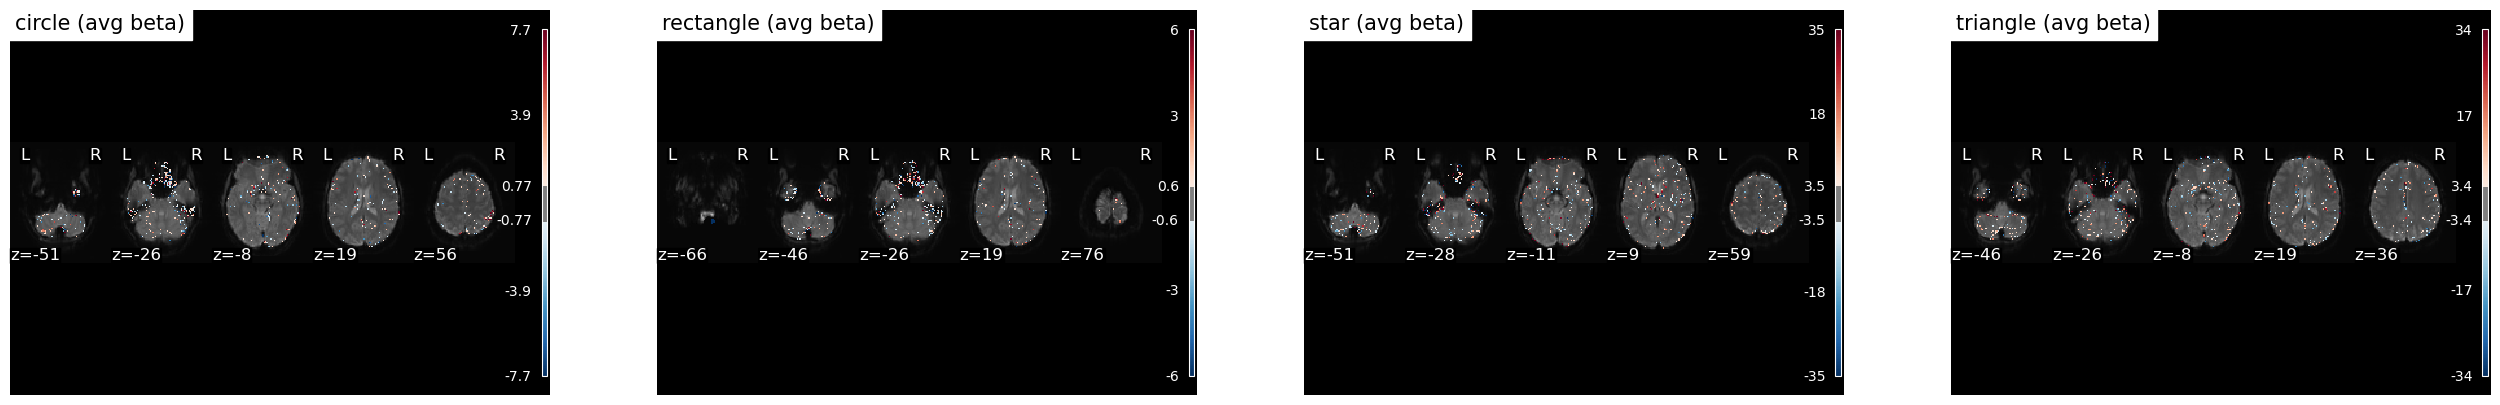

In [15]:
mean_bold_img = image.mean_img(bold_img)

fig, axes = plt.subplots(1, len(unique_conds), figsize=(8 * len(unique_conds), 5))
if len(unique_conds) == 1:
    axes = [axes]

for ax, cond in zip(axes, unique_conds):
    beta_masked = avg_betas[cond].copy()
    beta_masked[~brain_mask] = 0
    vmax_cond = float(np.percentile(np.abs(beta_masked[brain_mask]), 99))
    img = nib.Nifti1Image(beta_masked, bold_img.affine)
    plotting.plot_stat_map(
        img,
        bg_img=mean_bold_img,
        title=f'{cond} (avg beta)',
        display_mode='z',
        cut_coords=5,
        draw_cross=False,
        colorbar=True,
        vmax=vmax_cond,
        threshold=vmax_cond * 0.1,
        axes=ax,
    )
plt.show()

## 10. Save NIfTI outputs

Save results as standard NIfTI files (compatible with FSLeyes, ITK-SNAP, MRIcroGL, etc.).

In [16]:
# Average beta map per condition
for cond, beta_map in avg_betas.items():
    out_path = os.path.join(output_dir, f'sub-001_task-perceptXbind_{cond}_avg-betas.nii.gz')
    nib.Nifti1Image(beta_map, bold_img.affine).to_filename(out_path)
    print('Saved:', out_path)

# 4D single-trial betas: volume i = beta for the i-th valid trial in ascending events-row order
betas_4d_out = os.path.join(output_dir, 'sub-001_task-perceptXbind_single-trial-betas_4D.nii.gz')
nib.Nifti1Image(betas, bold_img.affine).to_filename(betas_4d_out)
print('Saved:', betas_4d_out)

# Trial metadata for MVPA: one row per valid trial, same order as betas volumes
meta_out = os.path.join(output_dir, 'sub-001_task-perceptXbind_valid-trial-metadata.csv')
valid_events[['trial_type', 'block']].to_csv(meta_out, index_label='events_row')
print('Saved:', meta_out)


Saved: /usr/people/ao8210/neu502b/results/pseudoruns/sub-001_task-perceptXbind_circle_avg-betas.nii.gz
Saved: /usr/people/ao8210/neu502b/results/pseudoruns/sub-001_task-perceptXbind_rectangle_avg-betas.nii.gz
Saved: /usr/people/ao8210/neu502b/results/pseudoruns/sub-001_task-perceptXbind_star_avg-betas.nii.gz
Saved: /usr/people/ao8210/neu502b/results/pseudoruns/sub-001_task-perceptXbind_triangle_avg-betas.nii.gz
Saved: /usr/people/ao8210/neu502b/results/pseudoruns/sub-001_task-perceptXbind_single-trial-betas_4D.nii.gz
Saved: /usr/people/ao8210/neu502b/results/pseudoruns/sub-001_task-perceptXbind_valid-trial-metadata.csv
